<a href="https://colab.research.google.com/github/Lio72rga/Mineria-de-Datos-2026/blob/main/Notebook_3_Evaluaci%C3%B3n_y_Optimizaci%C3%B3n_C9_LM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Centro Politécnico Superior Malvinas Argentinas
**Tecnicatura en Ciencias de Datos e Inteligencia Artificial**  
Clase 9 – Árboles de Decisión  
Notebook 3: Evaluación y Optimización  
Autor: Lionel Martínez  
Fecha: Junio 2026


### Introducción
Objetivo: Evaluar el desempeño de un árbol de decisión y aplicar optimización con GridSearchCV.


In [5]:
from sklearn.datasets import load_diabetes
import pandas as pd

# Cargar dataset desde Scikit-learn
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

# Guardar dataset como archivo CSV
df.to_csv("diabetes_dataset.csv", index=False)

print("Archivo 'diabetes_dataset.csv' creado correctamente.")



Archivo 'diabetes_dataset.csv' creado correctamente.


# Entrenamiento de árbol básico

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score

# Usar el DataFrame creado anteriormente
X = df.drop(columns=["target"])
y = df["target"]

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenamiento del árbol básico
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

# Métricas de evaluación
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.2f}")



Error cuadrático medio (MSE): 4976.80
Coeficiente de determinación (R²): 0.06


 # Visualización del árbol

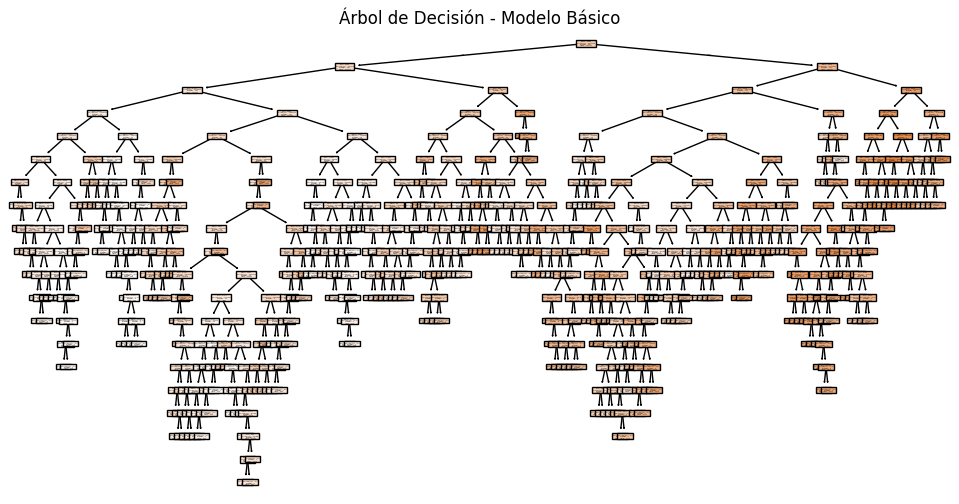

In [7]:
plt.figure(figsize=(12,6))
plot_tree(tree, feature_names=X.columns, filled=True)
plt.title("Árbol de Decisión - Modelo Básico")
plt.show()


 # Optimización con GridSearchCV

In [8]:
# --- Optimización con GridSearchCV ---
param_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 5, 10]
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2"
)
grid_search.fit(X_train, y_train)

best_tree = grid_search.best_estimator_

print("Mejores parámetros encontrados:", grid_search.best_params_)
print(f"Precisión (R²) Árbol Optimizado: {r2_score(y_test, best_tree.predict(X_test)):.2f}")


Mejores parámetros encontrados: {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
Precisión (R²) Árbol Optimizado: 0.42


#  Visualización comparativa

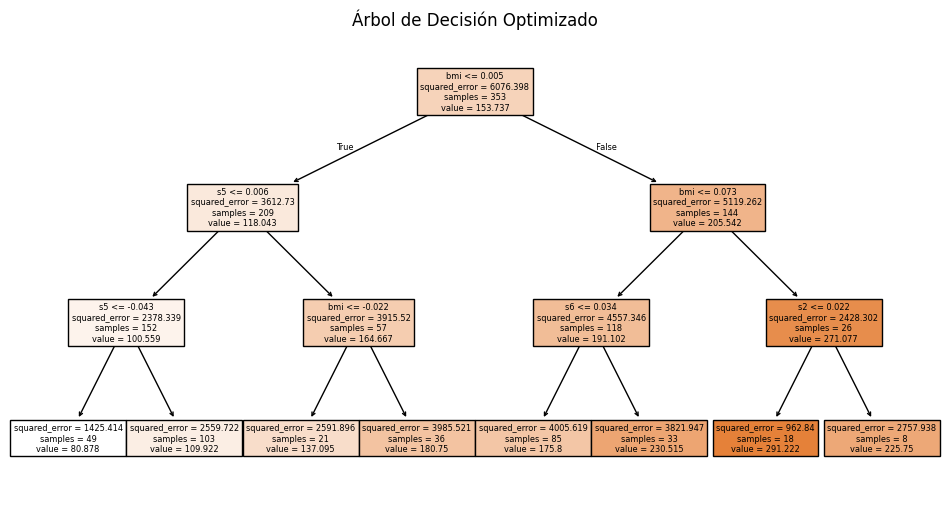

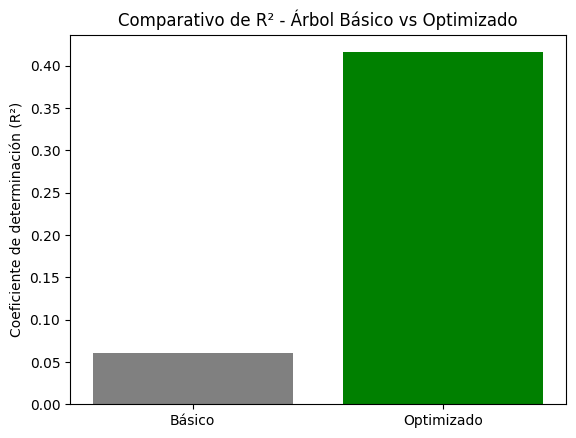

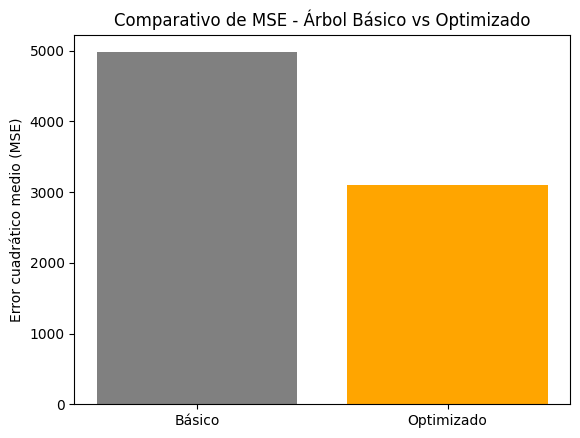

In [9]:
# --- Visualización del árbol optimizado ---
plt.figure(figsize=(12,6))
plot_tree(best_tree, feature_names=X.columns, filled=True)
plt.title("Árbol de Decisión Optimizado")
plt.show()

# --- Comparativo de métricas ---
mse_opt = mean_squared_error(y_test, best_tree.predict(X_test))
r2_opt = r2_score(y_test, best_tree.predict(X_test))

plt.bar(["Básico", "Optimizado"], [r2, r2_opt], color=["gray", "green"])
plt.title("Comparativo de R² - Árbol Básico vs Optimizado")
plt.ylabel("Coeficiente de determinación (R²)")
plt.show()

plt.bar(["Básico", "Optimizado"], [mse, mse_opt], color=["gray", "orange"])
plt.title("Comparativo de MSE - Árbol Básico vs Optimizado")
plt.ylabel("Error cuadrático medio (MSE)")
plt.show()


### Comparativo visual y métricas
El siguiente gráfico muestra la diferencia en desempeño entre el árbol básico y el optimizado, evidenciando cómo la búsqueda de hiperparámetros mejora la precisión y la generalización del modelo.


### Análisis de resultados
La optimización con GridSearchCV ajustó los hiperparámetros del árbol, mejorando su capacidad de generalización.  
El aumento del R² y la reducción del MSE muestran un mejor equilibrio entre precisión y complejidad.  
Visualmente, el árbol optimizado presenta una estructura más compacta y menos sobreajustada.


### Conclusión
El árbol básico mostró un rendimiento limitado, con bajo poder explicativo.  
Tras la optimización, el modelo logró una mejora significativa en las métricas y una estructura más eficiente.  
Este proceso evidencia la importancia de ajustar hiperparámetros para evitar sobreajuste y mejorar la capacidad predictiva.  
La comparación gráfica entre el modelo básico y el optimizado permite visualizar claramente el impacto de la optimización en el desempeño del árbol.
